# Model Evaluation (Load Pretrained Models Only)

This notebook evaluates already-trained models from artifacts, without retraining.

Goals:
1. Load saved model artifacts.
2. Evaluate model quality on newer data slices.
3. Report metrics and generate diagnostic plots for performance monitoring.


## Training Provenance (Where These Models Are Trained)

### Quantile GradientBoostingRegressor models
- Core training implementation: `core/models/probabilistic_quantile.py`
- Main training method: `fit_quantile_models(...)`
- Pipeline wrapper that trains/saves per coin: `core/pipelines/train_quantile_models.py` via `train_one_coin(...)`
- Saved artifact path used here: `artifacts/models/<coin-ticker>/quantile_model_bundle.joblib`

### Regime AutoEncoder + KNN matching
- AutoEncoder architecture: `core/models/regime_autoencoder.py` (`RegimeAutoencoder`)
- AutoEncoder training method: `core/regime_detection/historical_matching.py` -> `train_autoencoder(...)`
- KNN fitting/search method: `core/regime_detection/historical_matching.py` -> `find_top_n_similar_windows(...)`
- Orchestration entrypoint: `core/regime_detection/regime_detection.py` -> `run_regime_historical_matching(...)`
- Saved artifacts used here:
  - `artifacts/models/<coin-ticker>/regime_ae.pt`
  - `artifacts/models/<coin-ticker>/regime_scaler.pkl`
  - `artifacts/models/<coin-ticker>/regime_train_config.pkl`

Note: This notebook only loads and evaluates these artifacts; it does not call training methods.


In [1]:
from pathlib import Path
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch

from IPython.display import display
from sklearn.neighbors import NearestNeighbors

ROOT = Path.cwd().resolve()
if not (ROOT / 'core').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from core.models.probabilistic_quantile import (
    add_next_day_target,
    prepare_model_frame,
    predict_quantiles,
)
from core.models.regime_autoencoder import RegimeAutoencoder
from core.regime_detection.historical_matching import FEATURE_COLUMNS, build_rolling_windows

print('Project root:', ROOT)


Project root: C:\Users\sia\Desktop\capstone\src\Agentic-Crypto-Return-Service


In [2]:
# ------------------------------
# Paths and evaluation config
# ------------------------------
FEATURE_DIR = ROOT / 'data' / 'processed' / 'features'

ARTIFACTS_MODEL = ROOT / 'artifacts' / 'model'
ARTIFACTS_MODELS = ROOT / 'artifacts' / 'models'
ARTIFACTS_ROOT = ARTIFACTS_MODEL if ARTIFACTS_MODEL.exists() else ARTIFACTS_MODELS

EVAL_RECENT_FRACTION = 0.20        # evaluate on latest 20% rows as "new data"
MIN_EVAL_ROWS = 120
REGIME_REF_FRACTION = 0.80         # first 80% reference, last 20% recent
REGIME_MIN_RECENT_WINDOWS = 20

print('Using artifacts root:', ARTIFACTS_ROOT)
print('Feature dir:', FEATURE_DIR)


Using artifacts root: C:\Users\sia\Desktop\capstone\src\Agentic-Crypto-Return-Service\artifacts\models
Feature dir: C:\Users\sia\Desktop\capstone\src\Agentic-Crypto-Return-Service\data\processed\features


In [3]:
# ------------------------------
# Shared helpers
# ------------------------------
def load_features_safe(fp: Path) -> pd.DataFrame:
    df = pd.read_csv(fp)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
    if 'close' in df.columns:
        df['close'] = pd.to_numeric(df['close'], errors='coerce')
        df = df.dropna(subset=['close']).reset_index(drop=True)
    return df


def pinball_loss(y_true: np.ndarray, y_pred: np.ndarray, q: float) -> float:
    e = y_true - y_pred
    return float(np.mean(np.maximum(q * e, (q - 1.0) * e)))


def quantile_crossing_rate(qpred: pd.DataFrame, quantiles: list[float]) -> float:
    cols = [f'q_{q:.2f}' for q in sorted(quantiles)]
    arr = qpred[cols].to_numpy(dtype=float)
    crossing = np.any(np.diff(arr, axis=1) < 0, axis=1)
    return float(np.mean(crossing))


def get_feature_file_for_ticker(ticker: str) -> Path | None:
    symbol = ticker.split('-')[0]
    direct = FEATURE_DIR / f'{symbol}_features.csv'
    if direct.exists():
        return direct

    for fp in FEATURE_DIR.glob('*_features.csv'):
        try:
            d = pd.read_csv(fp, usecols=['ticker'], nrows=200)
            if d['ticker'].astype(str).str.upper().eq(ticker.upper()).any():
                return fp
        except Exception:
            continue
    return None


## A) Quantile GradientBoosting Evaluation (Loaded Bundles)

Evaluation protocol:
- Load each saved quantile bundle.
- Rebuild model frame using bundle feature columns.
- Evaluate on a recent slice of data (latest period) to detect potential degradation.

Reported metrics:
- `MAE`, `RMSE`, direction accuracy for `q_0.50`
- interval coverage in `[q_0.05, q_0.95]`
- mean pinball loss across quantiles
- quantile crossing rate
- mean absolute calibration error


In [4]:
quant_metrics_rows = []
quant_pinball_rows = []
quant_cal_rows = []
quant_preds = {}
quant_errors = []

coin_dirs = [d for d in ARTIFACTS_ROOT.iterdir() if d.is_dir()]

for cdir in sorted(coin_dirs, key=lambda p: p.name):
    ticker = cdir.name
    bundle_path = cdir / 'quantile_model_bundle.joblib'
    if not bundle_path.exists():
        continue

    try:
        obj = joblib.load(bundle_path)
        bundle = obj['bundle']
        quantiles = sorted([float(q) for q in bundle.quantiles])
        feature_cols = list(bundle.feature_cols)

        fp = get_feature_file_for_ticker(ticker)
        if fp is None:
            raise FileNotFoundError(f'Feature file not found for {ticker}')

        df = load_features_safe(fp)
        df = add_next_day_target(df, ret_col='log_ret_1d')
        model_df, _, target_col = prepare_model_frame(df, feature_cols=feature_cols)

        train_rows = int(obj.get('train_rows', -1))
        if 0 < train_rows < len(model_df):
            eval_df = model_df.iloc[train_rows:].copy()
        else:
            n_recent = max(MIN_EVAL_ROWS, int(len(model_df) * EVAL_RECENT_FRACTION))
            eval_df = model_df.tail(n_recent).copy()

        if len(eval_df) < max(40, MIN_EVAL_ROWS // 3):
            raise ValueError(f'Not enough eval rows ({len(eval_df)})')

        qpred = predict_quantiles(bundle, eval_df)
        y_true = eval_df[target_col].to_numpy(dtype=float)

        q50 = qpred['q_0.50'].to_numpy(dtype=float)
        mae = float(np.mean(np.abs(q50 - y_true)))
        rmse = float(np.sqrt(np.mean((q50 - y_true) ** 2)))
        dir_acc = float(np.mean(np.sign(q50) == np.sign(y_true)))

        coverage_90 = np.nan
        if 'q_0.05' in qpred.columns and 'q_0.95' in qpred.columns:
            coverage_90 = float(np.mean((y_true >= qpred['q_0.05'].to_numpy(dtype=float)) & (y_true <= qpred['q_0.95'].to_numpy(dtype=float))))

        pinball_vals = []
        cal_err_vals = []
        for q in quantiles:
            col = f'q_{q:.2f}'
            pv = pinball_loss(y_true, qpred[col].to_numpy(dtype=float), q)
            ec = float(np.mean(y_true <= qpred[col].to_numpy(dtype=float)))
            ce = abs(ec - q)
            pinball_vals.append(pv)
            cal_err_vals.append(ce)
            quant_pinball_rows.append({'ticker': ticker, 'quantile': q, 'pinball_loss': pv})
            quant_cal_rows.append({'ticker': ticker, 'quantile': q, 'nominal_q': q, 'empirical_coverage': ec, 'abs_calibration_error': ce})

        cross_rate = quantile_crossing_rate(qpred, quantiles)

        quant_metrics_rows.append({
            'ticker': ticker,
            'n_eval': int(len(eval_df)),
            'mae_q50': mae,
            'rmse_q50': rmse,
            'direction_accuracy_q50': dir_acc,
            'coverage_90': coverage_90,
            'mean_pinball': float(np.mean(pinball_vals)),
            'crossing_rate': cross_rate,
            'mean_abs_cal_error': float(np.mean(cal_err_vals)),
            'eval_start': pd.to_datetime(eval_df['date'].iloc[0]),
            'eval_end': pd.to_datetime(eval_df['date'].iloc[-1]),
        })

        quant_preds[ticker] = pd.DataFrame({
            'date': pd.to_datetime(eval_df['date']).to_numpy(),
            'y_true': y_true,
            'q_0.50': q50,
            'q_0.05': qpred['q_0.05'].to_numpy(dtype=float) if 'q_0.05' in qpred.columns else np.nan,
            'q_0.95': qpred['q_0.95'].to_numpy(dtype=float) if 'q_0.95' in qpred.columns else np.nan,
        })

    except Exception as e:
        quant_errors.append({'ticker': ticker, 'error': str(e)})

quant_metrics_df = pd.DataFrame(quant_metrics_rows).sort_values('ticker').reset_index(drop=True)
quant_pinball_df = pd.DataFrame(quant_pinball_rows).sort_values(['ticker', 'quantile']).reset_index(drop=True)
quant_cal_df = pd.DataFrame(quant_cal_rows).sort_values(['ticker', 'quantile']).reset_index(drop=True)
quant_errors_df = pd.DataFrame(quant_errors)

print('Quantile models evaluated:', len(quant_metrics_df))
print('Quantile evaluation errors:', len(quant_errors_df))
if not quant_errors_df.empty:
    display(quant_errors_df)

display(quant_metrics_df)


C:\Users\sia\AppData\Local\Temp\ipykernel_38740\2160540244.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')
C:\Users\sia\AppData\Local\Temp\ipykernel_38740\2160540244.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


Quantile models evaluated: 10
Quantile evaluation errors: 0


,ticker,n_eval,mae_q50,rmse_q50,direction_accuracy_q50,coverage_90,mean_pinball,crossing_rate,mean_abs_cal_error,eval_start,eval_end
0,ADA-USD,677,0.032542,0.044566,0.454948,0.927622,0.007850,0.008863,0.017988,2025-03-26,2026-02-27
1,AVAX-USD,468,0.032821,0.047556,0.653846,0.925214,0.008091,0.008547,0.019563,2025-07-08,2026-02-27
2,BNB-USD,868,0.016575,0.026387,0.718894,0.925115,0.004187,0.154378,0.012642,2024-12-20,2026-02-27
3,BTC-USD,1265,0.014431,0.022570,0.740711,0.917787,0.003594,0.097233,0.011621,2024-06-04,2026-02-27
4,DOGE-USD,677,0.035234,0.048229,0.412112,0.905465,0.008323,0.005908,0.016238,2025-03-26,2026-02-27
5,ETH-USD,1045,0.021407,0.034599,0.738756,0.901435,0.005500,0.165550,0.008410,2024-09-22,2026-02-27
6,FLOKI-USD,587,0.033658,0.054176,0.652470,0.902896,0.008742,0.277683,0.010759,2025-05-10,2026-02-27
7,LINK-USD,677,0.033716,0.045873,0.410635,0.935007,0.008085,0.011817,0.018076,2025-03-26,2026-02-27
8,SOL-USD,643,0.022886,0.034841,0.765163,0.942457,0.005933,0.153966,0.024323,2025-04-12,2026-02-27
9,XRP-USD,608,0.031065,0.047460,0.472039,0.906250,0.007886,0.044408,0.009686,2024-08-03,2026-02-27


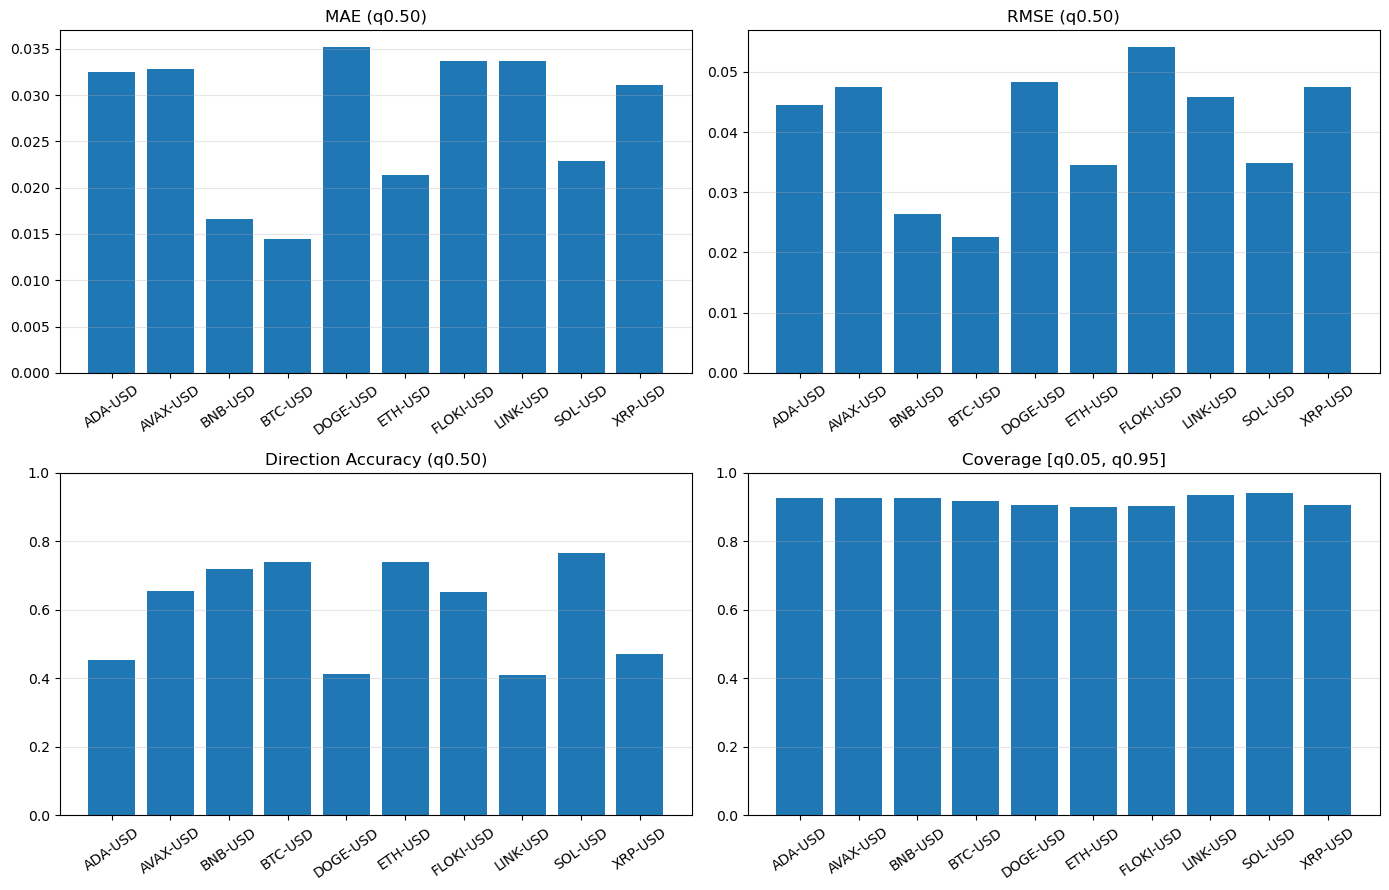

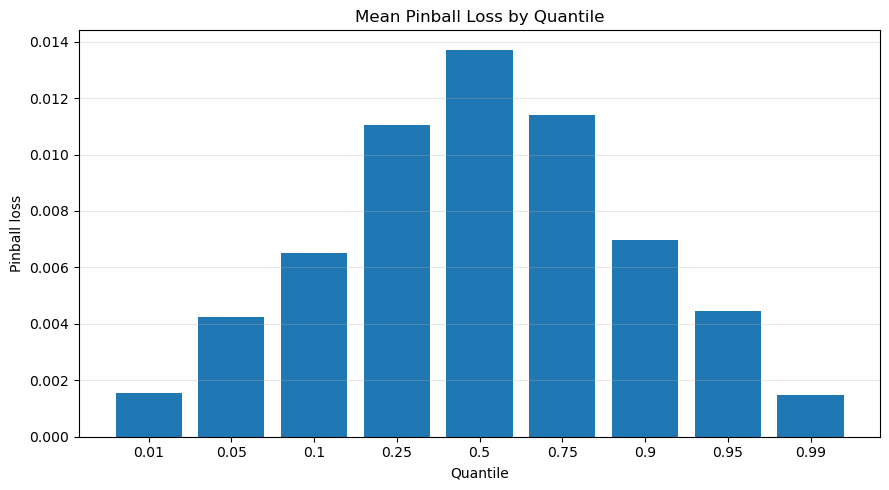

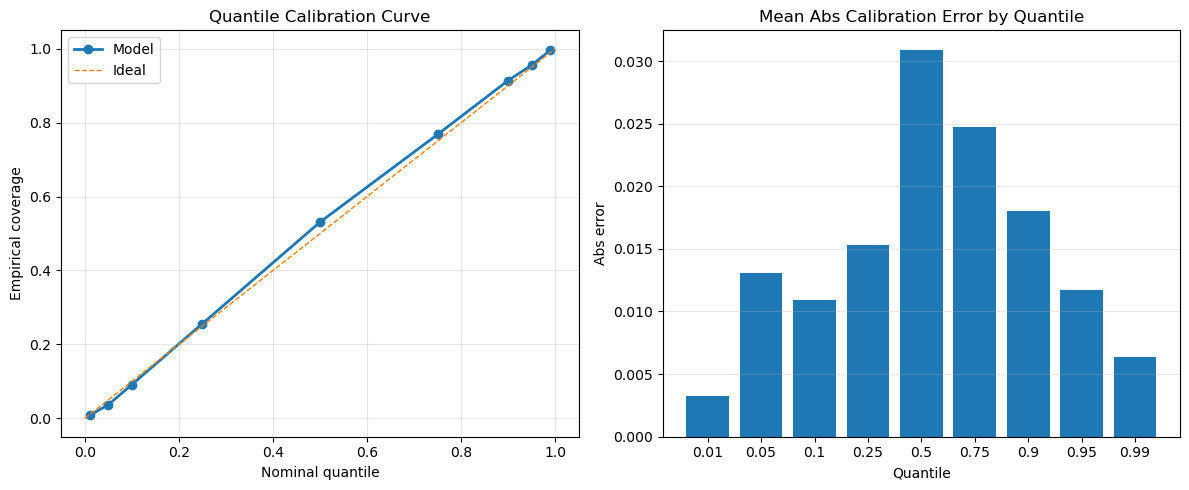

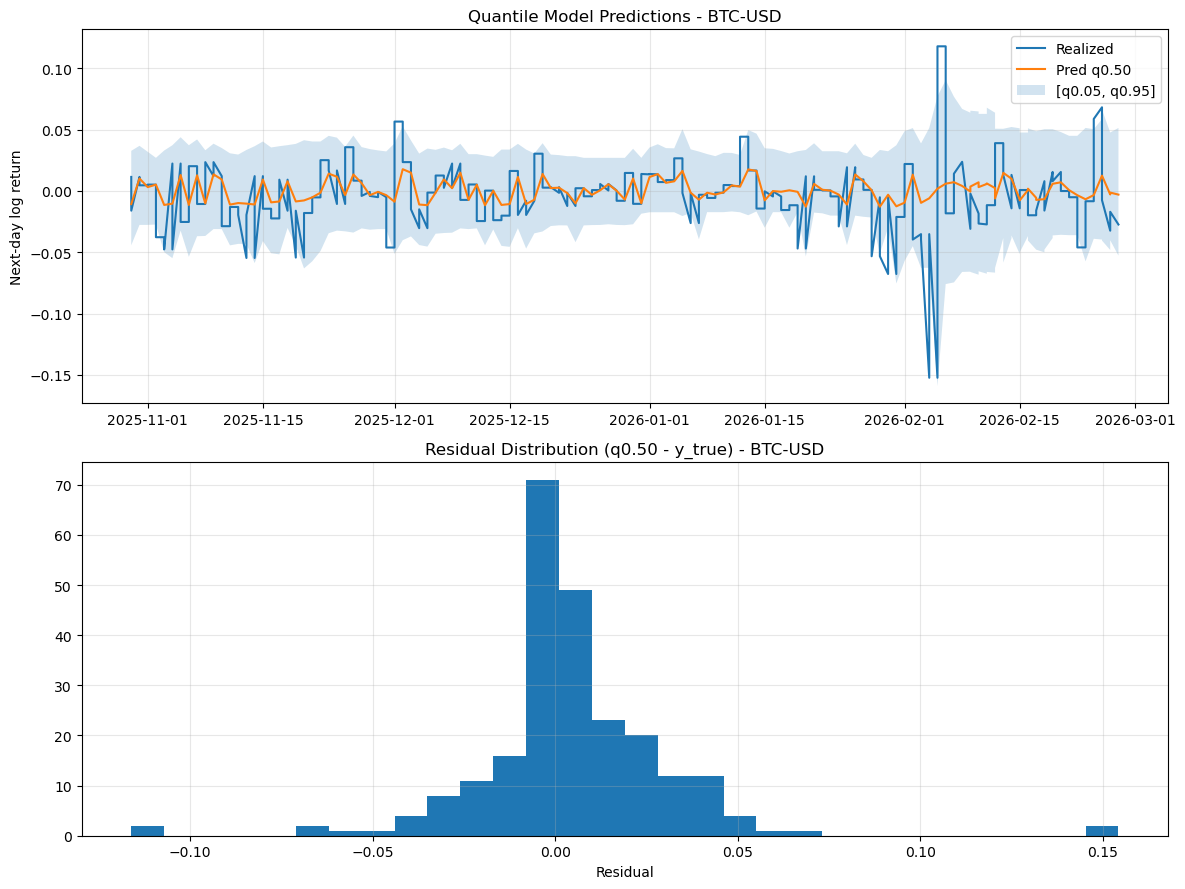

In [5]:
if quant_metrics_df.empty:
    raise RuntimeError('No quantile model evaluation results available.')

# Plot A1: per-coin key metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
mdf = quant_metrics_df.sort_values('ticker')

axes[0, 0].bar(mdf['ticker'], mdf['mae_q50'])
axes[0, 0].set_title('MAE (q0.50)')
axes[0, 0].tick_params(axis='x', rotation=35)
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].bar(mdf['ticker'], mdf['rmse_q50'])
axes[0, 1].set_title('RMSE (q0.50)')
axes[0, 1].tick_params(axis='x', rotation=35)
axes[0, 1].grid(axis='y', alpha=0.3)

axes[1, 0].bar(mdf['ticker'], mdf['direction_accuracy_q50'])
axes[1, 0].set_title('Direction Accuracy (q0.50)')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis='x', rotation=35)
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].bar(mdf['ticker'], mdf['coverage_90'])
axes[1, 1].set_title('Coverage [q0.05, q0.95]')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis='x', rotation=35)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Plot A2: mean pinball by quantile (across coins)
pb = quant_pinball_df.groupby('quantile', as_index=False)['pinball_loss'].mean()
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(pb['quantile'].astype(str), pb['pinball_loss'])
ax.set_title('Mean Pinball Loss by Quantile')
ax.set_xlabel('Quantile')
ax.set_ylabel('Pinball loss')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot A3: calibration curve
cal = quant_cal_df.groupby('quantile', as_index=False).agg(
    nominal_q=('nominal_q', 'mean'),
    empirical_coverage=('empirical_coverage', 'mean'),
    abs_calibration_error=('abs_calibration_error', 'mean'),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(cal['nominal_q'], cal['empirical_coverage'], marker='o', linewidth=2, label='Model')
axes[0].plot([0, 1], [0, 1], linestyle='--', linewidth=1, label='Ideal')
axes[0].set_title('Quantile Calibration Curve')
axes[0].set_xlabel('Nominal quantile')
axes[0].set_ylabel('Empirical coverage')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].bar(cal['quantile'].astype(str), cal['abs_calibration_error'])
axes[1].set_title('Mean Abs Calibration Error by Quantile')
axes[1].set_xlabel('Quantile')
axes[1].set_ylabel('Abs error')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Plot A4: sample coin prediction diagnostics
sample = 'BTC-USD' if 'BTC-USD' in quant_preds else list(quant_preds.keys())[0]
g = quant_preds[sample].sort_values('date').tail(240)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))
axes[0].plot(g['date'], g['y_true'], label='Realized')
axes[0].plot(g['date'], g['q_0.50'], label='Pred q0.50')
if g['q_0.05'].notna().any() and g['q_0.95'].notna().any():
    axes[0].fill_between(g['date'], g['q_0.05'], g['q_0.95'], alpha=0.2, label='[q0.05, q0.95]')
axes[0].set_title(f'Quantile Model Predictions - {sample}')
axes[0].set_ylabel('Next-day log return')
axes[0].grid(alpha=0.3)
axes[0].legend()

res = g['q_0.50'] - g['y_true']
axes[1].hist(res, bins=30)
axes[1].set_title(f'Residual Distribution (q0.50 - y_true) - {sample}')
axes[1].set_xlabel('Residual')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## B) Regime AutoEncoder + KNN Evaluation (Loaded Artifacts)

Evaluation protocol:
- Load saved `regime_ae.pt`, `regime_scaler.pkl`, `regime_train_config.pkl`.
- Rebuild rolling windows from current feature data.
- Compute reconstruction error (AE quality).
- Evaluate KNN distances in latent space on recent windows vs reference history.

Degradation indicators:
- Increase in recent reconstruction error vs baseline.
- Increase in recent nearest-neighbor distances vs historical structure.


In [6]:
regime_metrics_rows = []
regime_recon_series = {}
regime_knn_recent_series = {}
regime_errors = []

for cdir in sorted(coin_dirs, key=lambda p: p.name):
    ticker = cdir.name
    ae_path = cdir / 'regime_ae.pt'
    scaler_path = cdir / 'regime_scaler.pkl'
    cfg_path = cdir / 'regime_train_config.pkl'

    if not (ae_path.exists() and scaler_path.exists() and cfg_path.exists()):
        continue

    try:
        with open(scaler_path, 'rb') as f:
            scaler = pickle.load(f)
        with open(cfg_path, 'rb') as f:
            train_cfg = pickle.load(f)

        match_window_days = int(train_cfg.get('match_window_days', 30))
        latent_dim = int(train_cfg.get('latent_dim', 16))
        sim_metric = str(train_cfg.get('similarity_metric', 'cosine')).lower()
        top_n = int(train_cfg.get('top_n', 10)) if 'top_n' in train_cfg else 10

        fp = get_feature_file_for_ticker(ticker)
        if fp is None:
            raise FileNotFoundError(f'Feature file not found for {ticker}')

        df_raw = load_features_safe(fp)

        # build scaled windows
        df_scaled = df_raw.copy()
        df_scaled[FEATURE_COLUMNS] = scaler.transform(df_scaled[FEATURE_COLUMNS])
        windows, window_end_indices = build_rolling_windows(df_scaled, match_window_days=match_window_days)

        if windows.size == 0:
            raise ValueError('No valid windows produced')

        N, W, F = windows.shape
        X = windows.reshape(N, W * F).astype(np.float32)
        X_t = torch.from_numpy(X)

        model = RegimeAutoencoder(input_dim=W * F, latent_dim=latent_dim)
        model.load_state_dict(torch.load(ae_path, map_location='cpu'))
        model.eval()

        with torch.no_grad():
            recon = model(X_t).numpy()
            Z = model.encode(X_t).numpy()

        recon_mse = np.mean((recon - X) ** 2, axis=1)

        # map window to end date (inclusive)
        end_dates = pd.to_datetime([df_raw.loc[e_idx - 1, 'date'] for e_idx in window_end_indices])

        # split reference vs recent
        split = int(len(Z) * REGIME_REF_FRACTION)
        split = max(20, min(split, len(Z) - REGIME_MIN_RECENT_WINDOWS))
        if len(Z) - split < REGIME_MIN_RECENT_WINDOWS:
            raise ValueError('Not enough recent windows for regime evaluation')

        Z_ref = Z[:split]
        Z_recent = Z[split:]
        mse_ref = recon_mse[:split]
        mse_recent = recon_mse[split:]
        date_recent = end_dates[split:]

        metric = 'cosine' if sim_metric == 'cosine' else 'euclidean'
        k = min(max(1, top_n), len(Z_ref))
        nn = NearestNeighbors(n_neighbors=k, metric=metric)
        nn.fit(Z_ref)
        dists, _ = nn.kneighbors(Z_recent, return_distance=True)

        min_dist = dists[:, 0]
        mean_k_dist = dists.mean(axis=1)

        regime_metrics_rows.append({
            'ticker': ticker,
            'n_windows': int(len(Z)),
            'n_recent': int(len(Z_recent)),
            'mean_recon_mse_ref': float(np.mean(mse_ref)),
            'mean_recon_mse_recent': float(np.mean(mse_recent)),
            'recon_mse_ratio_recent_over_ref': float(np.mean(mse_recent) / max(np.mean(mse_ref), 1e-12)),
            'knn_metric': metric,
            'knn_k': int(k),
            'mean_knn_min_dist_recent': float(np.mean(min_dist)),
            'p95_knn_min_dist_recent': float(np.percentile(min_dist, 95)),
            'mean_knn_k_dist_recent': float(np.mean(mean_k_dist)),
            'recent_start': pd.to_datetime(date_recent.iloc[0]) if hasattr(date_recent, 'iloc') else pd.to_datetime(date_recent[0]),
            'recent_end': pd.to_datetime(date_recent.iloc[-1]) if hasattr(date_recent, 'iloc') else pd.to_datetime(date_recent[-1]),
        })

        regime_recon_series[ticker] = pd.DataFrame({
            'date': end_dates,
            'recon_mse': recon_mse,
            'is_recent': np.array([0] * split + [1] * (len(Z) - split), dtype=int),
        })

        regime_knn_recent_series[ticker] = pd.DataFrame({
            'date': date_recent,
            'knn_min_dist': min_dist,
            'knn_mean_k_dist': mean_k_dist,
        })

    except Exception as e:
        regime_errors.append({'ticker': ticker, 'error': str(e)})

regime_metrics_df = pd.DataFrame(regime_metrics_rows).sort_values('ticker').reset_index(drop=True)
regime_errors_df = pd.DataFrame(regime_errors)

print('Regime artifacts evaluated:', len(regime_metrics_df))
print('Regime evaluation errors:', len(regime_errors_df))
if not regime_errors_df.empty:
    display(regime_errors_df)

display(regime_metrics_df)


C:\Users\sia\AppData\Local\Temp\ipykernel_38740\2160540244.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')
C:\Users\sia\AppData\Local\Temp\ipykernel_38740\2160540244.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


Regime artifacts evaluated: 10
Regime evaluation errors: 0


,ticker,n_windows,n_recent,mean_recon_mse_ref,mean_recon_mse_recent,recon_mse_ratio_recent_over_ref,knn_metric,knn_k,mean_knn_min_dist_recent,p95_knn_min_dist_recent,mean_knn_k_dist_recent,recent_start,recent_end
0,ADA-USD,3355,671,0.248641,0.196219,0.789164,cosine,10,0.075585,0.118064,0.096407,2025-03-29,2026-02-27
1,AVAX-USD,2309,462,0.247845,0.206248,0.832166,cosine,10,0.088990,0.138385,0.114044,2025-07-11,2026-02-27
2,BNB-USD,4311,863,0.221126,0.158347,0.716096,cosine,10,0.054443,0.106598,0.071998,2024-12-23,2026-02-27
3,BTC-USD,6293,1259,0.254630,0.178721,0.701885,cosine,10,0.065879,0.116782,0.085194,2024-06-07,2026-02-27
4,DOGE-USD,3355,671,0.222223,0.174126,0.783566,cosine,10,0.094217,0.156893,0.123081,2025-03-29,2026-02-27
5,ETH-USD,5192,1039,0.280059,0.233655,0.834309,cosine,10,0.063962,0.105244,0.082318,2024-09-25,2026-02-27
6,FLOKI-USD,2902,581,0.270480,0.181388,0.670615,cosine,10,0.057068,0.101473,0.073382,2025-05-13,2026-02-27
7,LINK-USD,3355,671,0.254612,0.195069,0.766142,cosine,10,0.070497,0.110426,0.091090,2025-03-29,2026-02-27
8,SOL-USD,3183,637,0.261872,0.173925,0.664163,cosine,10,0.067143,0.099913,0.085736,2025-04-15,2026-02-27
9,XRP-USD,3008,602,0.226905,0.189127,0.833506,cosine,10,0.088193,0.156984,0.120834,2024-08-09,2026-02-27


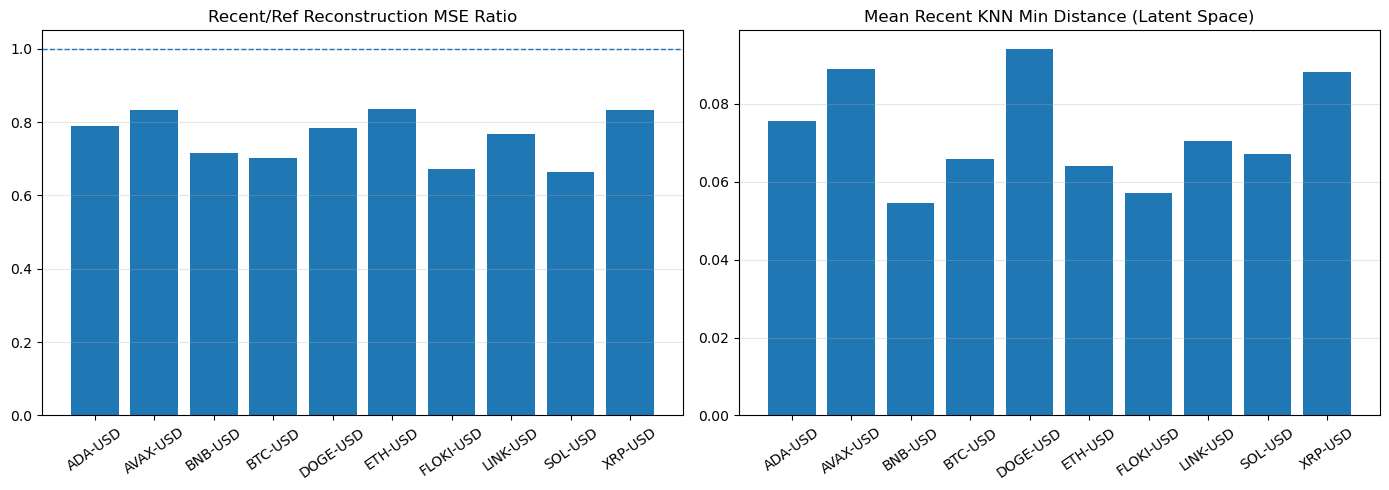

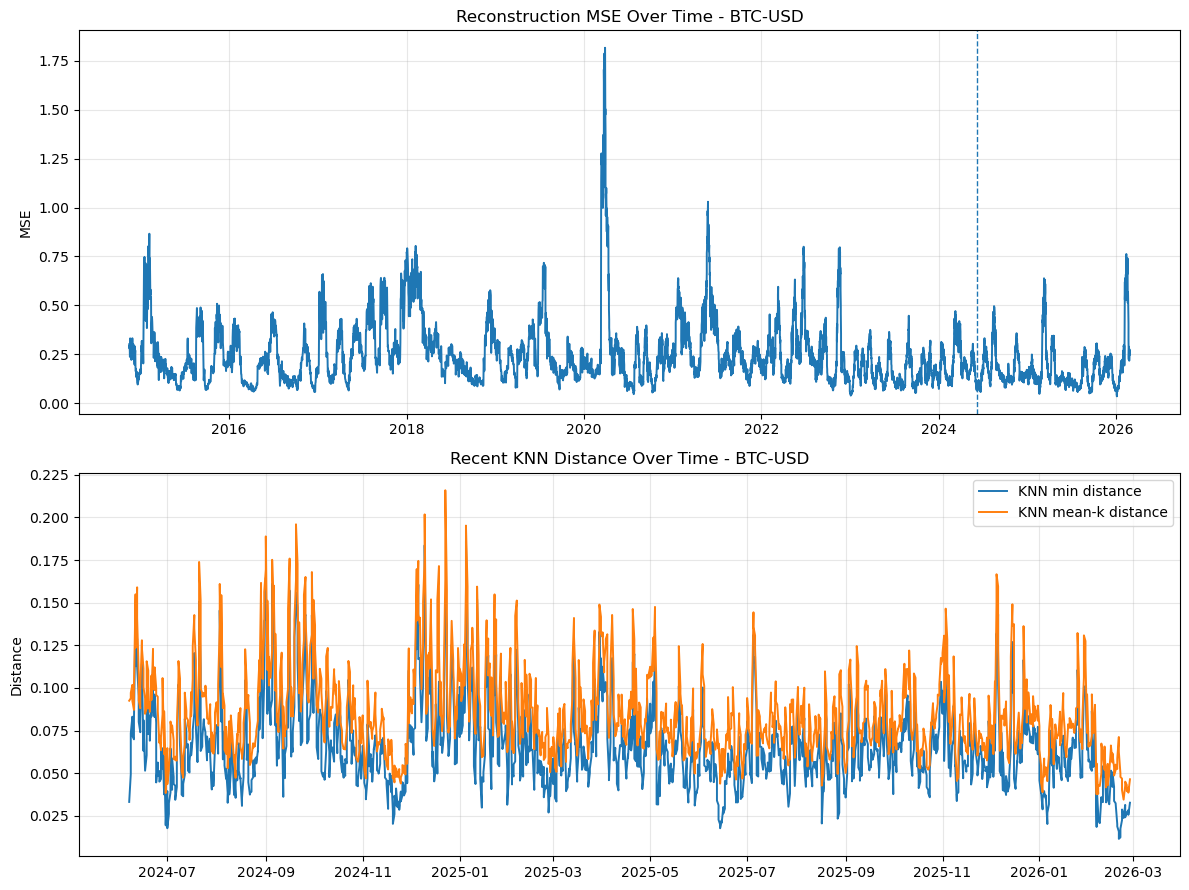

In [7]:
if regime_metrics_df.empty:
    raise RuntimeError('No regime evaluation results available.')

# Plot B1: degradation indicators per coin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rdf = regime_metrics_df.sort_values('ticker')

axes[0].bar(rdf['ticker'], rdf['recon_mse_ratio_recent_over_ref'])
axes[0].axhline(1.0, linestyle='--', linewidth=1)
axes[0].set_title('Recent/Ref Reconstruction MSE Ratio')
axes[0].tick_params(axis='x', rotation=35)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(rdf['ticker'], rdf['mean_knn_min_dist_recent'])
axes[1].set_title('Mean Recent KNN Min Distance (Latent Space)')
axes[1].tick_params(axis='x', rotation=35)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Plot B2: sample coin time-series diagnostics
sample = 'BTC-USD' if 'BTC-USD' in regime_recon_series else list(regime_recon_series.keys())[0]
recon_df = regime_recon_series[sample].sort_values('date')
knn_df = regime_knn_recent_series[sample].sort_values('date')

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

axes[0].plot(recon_df['date'], recon_df['recon_mse'], linewidth=1.4)
if recon_df['is_recent'].any():
    first_recent_date = recon_df.loc[recon_df['is_recent'] == 1, 'date'].iloc[0]
    axes[0].axvline(first_recent_date, linestyle='--', linewidth=1)
axes[0].set_title(f'Reconstruction MSE Over Time - {sample}')
axes[0].set_ylabel('MSE')
axes[0].grid(alpha=0.3)

axes[1].plot(knn_df['date'], knn_df['knn_min_dist'], label='KNN min distance', linewidth=1.4)
axes[1].plot(knn_df['date'], knn_df['knn_mean_k_dist'], label='KNN mean-k distance', linewidth=1.4)
axes[1].set_title(f'Recent KNN Distance Over Time - {sample}')
axes[1].set_ylabel('Distance')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## Final Output Tables

The following tables can be exported and monitored periodically:
- `quant_metrics_df`: quantile model health on recent data
- `quant_pinball_df`: per-quantile loss detail
- `quant_cal_df`: calibration detail
- `regime_metrics_df`: regime AE/KNN degradation indicators


In [8]:
display(quant_metrics_df)
display(regime_metrics_df)

# Optional exports
# quant_metrics_df.to_csv(ROOT / 'artifacts' / 'quant_metrics_eval.csv', index=False)
# quant_pinball_df.to_csv(ROOT / 'artifacts' / 'quant_pinball_eval.csv', index=False)
# quant_cal_df.to_csv(ROOT / 'artifacts' / 'quant_calibration_eval.csv', index=False)
# regime_metrics_df.to_csv(ROOT / 'artifacts' / 'regime_metrics_eval.csv', index=False)


,ticker,n_eval,mae_q50,rmse_q50,direction_accuracy_q50,coverage_90,mean_pinball,crossing_rate,mean_abs_cal_error,eval_start,eval_end
0,ADA-USD,677,0.032542,0.044566,0.454948,0.927622,0.007850,0.008863,0.017988,2025-03-26,2026-02-27
1,AVAX-USD,468,0.032821,0.047556,0.653846,0.925214,0.008091,0.008547,0.019563,2025-07-08,2026-02-27
2,BNB-USD,868,0.016575,0.026387,0.718894,0.925115,0.004187,0.154378,0.012642,2024-12-20,2026-02-27
3,BTC-USD,1265,0.014431,0.022570,0.740711,0.917787,0.003594,0.097233,0.011621,2024-06-04,2026-02-27
4,DOGE-USD,677,0.035234,0.048229,0.412112,0.905465,0.008323,0.005908,0.016238,2025-03-26,2026-02-27
5,ETH-USD,1045,0.021407,0.034599,0.738756,0.901435,0.005500,0.165550,0.008410,2024-09-22,2026-02-27
6,FLOKI-USD,587,0.033658,0.054176,0.652470,0.902896,0.008742,0.277683,0.010759,2025-05-10,2026-02-27
7,LINK-USD,677,0.033716,0.045873,0.410635,0.935007,0.008085,0.011817,0.018076,2025-03-26,2026-02-27
8,SOL-USD,643,0.022886,0.034841,0.765163,0.942457,0.005933,0.153966,0.024323,2025-04-12,2026-02-27
9,XRP-USD,608,0.031065,0.047460,0.472039,0.906250,0.007886,0.044408,0.009686,2024-08-03,2026-02-27


,ticker,n_windows,n_recent,mean_recon_mse_ref,mean_recon_mse_recent,recon_mse_ratio_recent_over_ref,knn_metric,knn_k,mean_knn_min_dist_recent,p95_knn_min_dist_recent,mean_knn_k_dist_recent,recent_start,recent_end
0,ADA-USD,3355,671,0.248641,0.196219,0.789164,cosine,10,0.075585,0.118064,0.096407,2025-03-29,2026-02-27
1,AVAX-USD,2309,462,0.247845,0.206248,0.832166,cosine,10,0.088990,0.138385,0.114044,2025-07-11,2026-02-27
2,BNB-USD,4311,863,0.221126,0.158347,0.716096,cosine,10,0.054443,0.106598,0.071998,2024-12-23,2026-02-27
3,BTC-USD,6293,1259,0.254630,0.178721,0.701885,cosine,10,0.065879,0.116782,0.085194,2024-06-07,2026-02-27
4,DOGE-USD,3355,671,0.222223,0.174126,0.783566,cosine,10,0.094217,0.156893,0.123081,2025-03-29,2026-02-27
5,ETH-USD,5192,1039,0.280059,0.233655,0.834309,cosine,10,0.063962,0.105244,0.082318,2024-09-25,2026-02-27
6,FLOKI-USD,2902,581,0.270480,0.181388,0.670615,cosine,10,0.057068,0.101473,0.073382,2025-05-13,2026-02-27
7,LINK-USD,3355,671,0.254612,0.195069,0.766142,cosine,10,0.070497,0.110426,0.091090,2025-03-29,2026-02-27
8,SOL-USD,3183,637,0.261872,0.173925,0.664163,cosine,10,0.067143,0.099913,0.085736,2025-04-15,2026-02-27
9,XRP-USD,3008,602,0.226905,0.189127,0.833506,cosine,10,0.088193,0.156984,0.120834,2024-08-09,2026-02-27
